In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from fsspec.utils import infer_compression

#### Loading in the Data
Using Pandas to open up the Excel file and do some data cleanup line aggregating sex and recalculating the rates since it used a lot of symbols that are not numbers. Then making a separate dataframe that's for statewide data as opposed to county data. Once we find a disease we want to study in further detail, we can use the county data to see if any county is contributing a lot to the increase/decrease in infection over time.
Also rate is calculated as:
$$ \frac{Cases}{Population} * 100,000 $$

The `find_largest_del` function takes in the county dataset and subsets it to the statewide dataset within the function because I'm bad at coding and too lazy to fix it because it works. It also takes in an argument `value_diff` for the thing you want the average of over the years, which means it either takes `'Rate'` or `'Cases'`. It then spits out a dictionary ordered by value so the user can see which diseases have the greatest average rate of change of rate or cases (which are connected so having both of them here is a little redundant but I think it's useful for intuition to have both of them here). I called the function twice and put the outputs into a dataframe to look at them side by side. A little counterintuitive but the negative numbers actually represent an increase from the previous year since if $year_{previous} < year_{current}$ then $sign(year_{previous} - year_{current}) = -1$

From this we can see that Coccidioidomycosis prevalence is increasing the most and Zika Virus prevalence dropping the most. Also that anthrax and whatever "Plague, human" is are both at a steady zero which is good I guess.

In [228]:
infection_df = pd.read_csv('./data/diseases.csv')
infection_df = infection_df[infection_df['Sex'] == 'Total']
infection_df = infection_df.assign(Rate = lambda x: np.round(((x['Cases']/x['Population'])*100_000), decimals = 3))
state_infection_df = infection_df[infection_df['County'] == 'California']

def find_largest_del(df, value_diff):
    '''
    Calculates the average difference between year-1 and year sequentially and averages them over all years for all diseases and places them in a value ordered dictionary

    Parameters:
        df: A pandas dataframe of infectious disease data with a rate column of numeric data and a sex column of total infections
        value_diff: A string that can take the value 'Cases' or 'Rate' and will do the calculation for the selected variable, if neither throws an error

    Returns:
        A value sorted dictionary with disease names as keys and average difference values as values
    '''
    if (value_diff == 'Cases') or (value_diff == 'Rate'):
        pass
    else:
        raise ValueError('value_diff must be either "Cases" or "Rate"')

    diseases = df['Disease'].drop_duplicates().reset_index(drop=True)
    statewide = df[df['County'] == 'California'].replace(to_replace='-', value=0)
    avg_del_infections = [0] * len(diseases)
    for j in range(len(diseases)):
        disease = diseases[j]
        tmp = statewide[statewide['Disease'] == disease]
        lbound = min(tmp['Year'])+1
        ubound = max(tmp['Year'])+1
        del_infections = [0] * len(range(lbound,ubound))

        for i in range(lbound,ubound):
            tmp_yr_minone = tmp[tmp['Year'] == i-1]
            tmp_yr = tmp[tmp['Year'] == i]
            diff = float(tmp_yr_minone[value_diff].iloc[0]) - float(tmp_yr[value_diff].iloc[0])
            del_infections[i-lbound] = diff
        avg_del_infections[j] = np.mean(del_infections)

    del_cases_dict = {diseases[i]:avg_del_infections[i] for i in range(len(diseases))}
    sorted_del_cases_dict = sorted(del_cases_dict.items(), key=lambda x:x[1])
    sorted_del_cases_dict = dict(sorted_del_cases_dict)
    return sorted_del_cases_dict


#input either 'Cases' or 'Rate' as value_diff
rates = find_largest_del(infection_df,value_diff='Rate')
cases = find_largest_del(infection_df,value_diff='Cases')
disease_comparison = pd.DataFrame([cases,rates]).transpose().rename(columns={0:'Cases',1:'Rate'})
disease_comparison

,Cases,Rate
Coccidioidomycosis,-343.772727,-0.859136
Campylobacteriosis,-291.000000,-0.661545
Salmonellosis,-130.590909,-0.272409
Shiga toxin-producing E. coli (STEC) without HUS,-111.181818,-0.281545
Shigellosis,-104.545455,-0.234864
Cryptosporidiosis,-35.090909,-0.086409
Yersiniosis,-34.681818,-0.087727
Legionellosis,-29.500000,-0.074818
Cyclosporiasis,-12.333333,-0.031667
Vibrio Infection (non-Cholera),-10.727273,-0.026364


#### Visualizing Infections over Time
This code block defines the diseases with the fastest growing incidence and the fastest declining incidence, mostly decided by looking at the comparison dataframe and choosing the ones that looked like they had the biggest average change not gonna lie. There's also a little function for preparing the data for visualization and then outputting a line graph.

The png files are accessible in the Figures folder.

In [239]:
top_increasing = list(disease_comparison.index[0:8])
top_decreasing = list(disease_comparison.index[47:52])
def visualize_tops(state_df, lst, lineplotted, loc, giardia = False):
    '''
    Visualizes the number of cases of the diseases with the most increasing or decreasing incidence with a line plot

    Parameters:
        state_df: A pandas dataframe containing statewide infection data
        lst: A list of the diseases with the most increasing or decreasing infections (or just a list of infections i guess
        lineplotted: A string that can take the value 'Cases' or 'Rate' and will line plot that statistic (but since one is just a transformation of the other they look the same)
        giardia: A boolean stating whether or not to include giardia in the final plot, I found that giardia highly skewed the original plot so I added this option
        loc: A string for the file path you want to save the figure to

    Returns:
        A seaborn lineplot
    '''
    if giardia == True or lst == top_increasing:
        pass
    else:
        lst.remove('Giardiasis')
    df = {lst[i]:list(state_df[state_df['Disease'] == lst[i]][lineplotted]) for i in range(len(lst))}
    df = pd.DataFrame.from_dict(df, orient='index')
    df = df.transpose()
    df.index = state_df['Year'].unique()
    if lst == top_decreasing:
        df[['Chikungunya Virus Infection', 'Zika Virus Infection']] = df[['Chikungunya Virus Infection', 'Zika Virus Infection']].shift(15)
    else:
        pass
    sns.set_theme(rc={'figure.figsize':(12,9)})
    plt = sns.lineplot(df)
    plt.get_figure().savefig(loc)
    return plt

<Axes: >

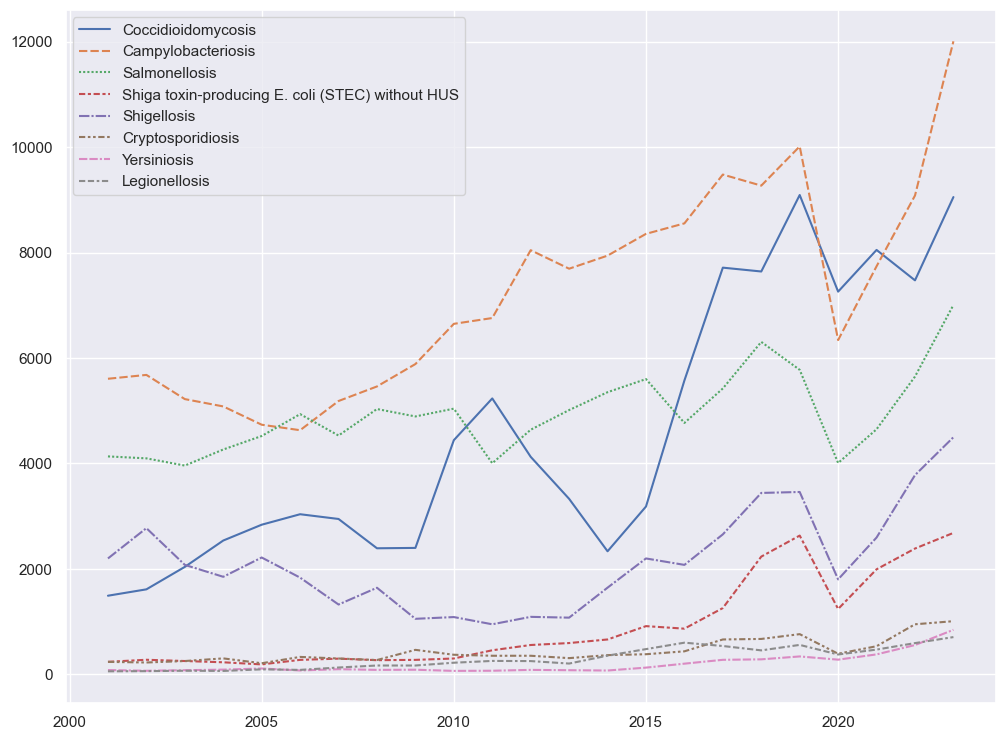

In [240]:
visualize_tops(state_infection_df, top_increasing, 'Cases', './Figures/most_increasing_diseases.png')

<Axes: >

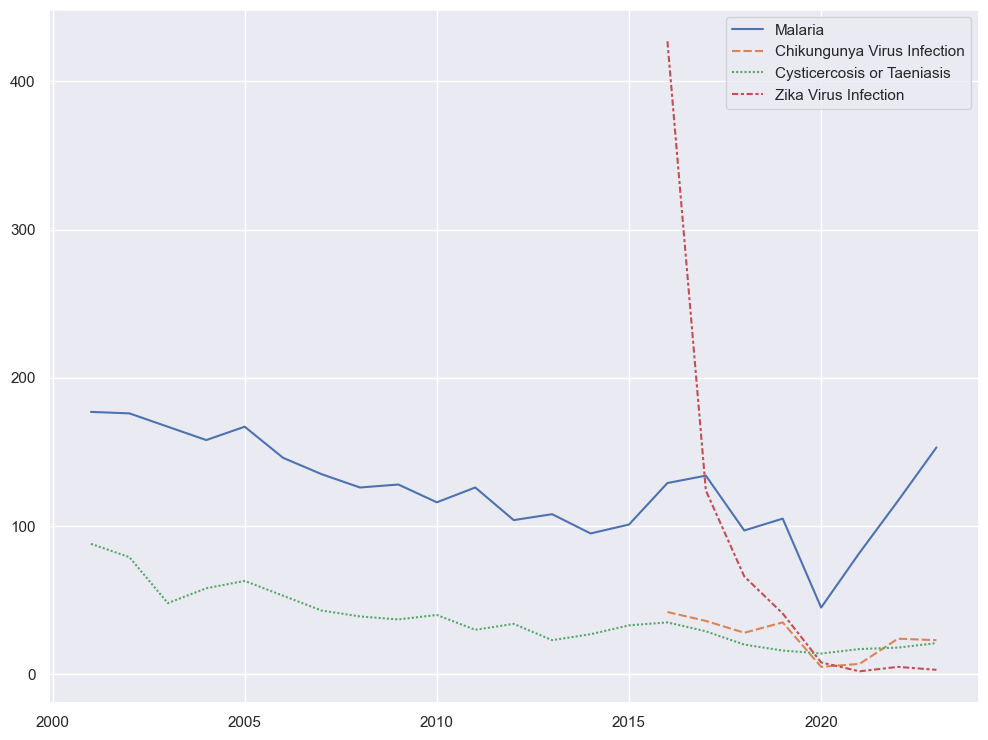

In [241]:
visualize_tops(state_infection_df, top_decreasing, 'Cases', './Figures/most_decreasing_diseases.png')

<Axes: >

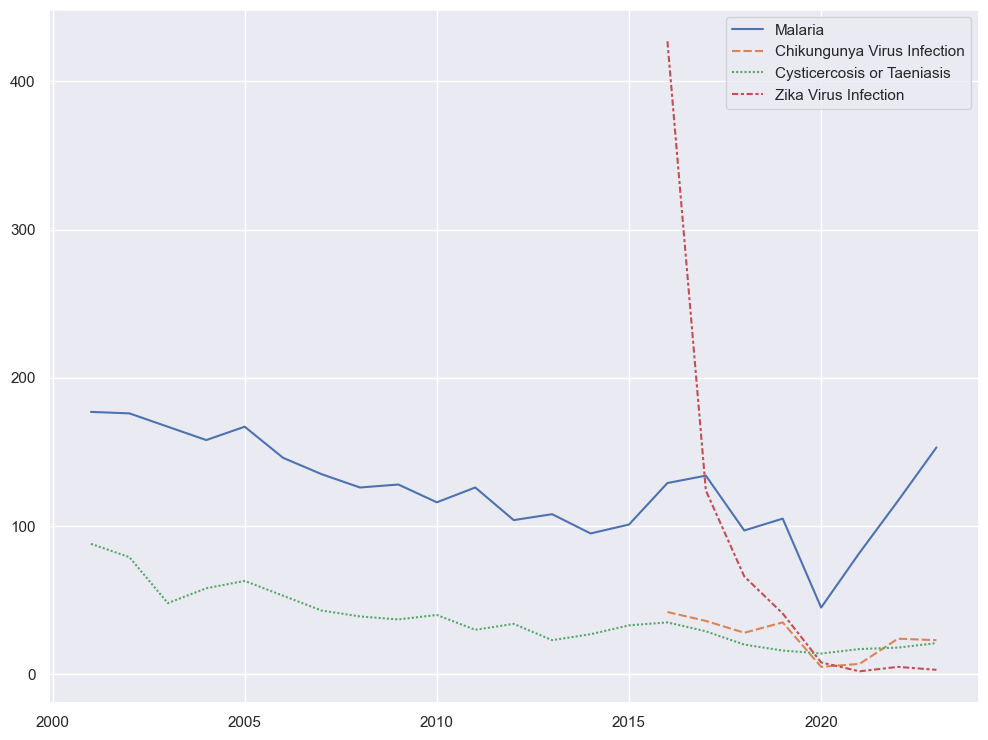

In [242]:
visualize_tops(state_infection_df, top_decreasing, 'Cases', './Figures/most_decreasing_diseases_giardia.png', giardia = True)